In [185]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import randint, uniform, loguniform

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay

from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline

#### Importing Dataset

In [186]:
data_dir = '../data/'

df = pd.read_csv(os.path.join(data_dir, 'combined.csv'))

df.head()

,Sample_ID,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,...,ENSG00000283907,ENSG00000283913,ENSG00000284032,ENSG00000284373,ENSG00000284387,ENSG00000284395,ENSG00000284505,ENSG00000284552,Disease,characteristics_ch1_bmi
0,GSM1501013,8.002176,0.175238,4.949994,3.285351,0.959516,0.672894,59.325067,4.168056,8.104327,...,3.031789,0.903138,1.222211,0.132392,0.491394,-0.079424,-0.255411,3.071849,normal control,27.1
1,GSM1501014,23.292853,-0.031148,5.657237,2.786927,1.203578,0.358625,46.002714,4.889903,7.588060,...,1.819534,-0.021741,0.487849,-0.066907,0.195198,0.178077,-0.190626,1.399320,healthy obese,30.5
2,GSM1501015,10.557890,0.097413,7.680354,2.795125,0.789783,0.733455,43.835288,5.133417,9.559194,...,1.914932,0.424076,0.423539,-0.155705,0.086307,0.230390,-0.489850,1.632879,normal control,25.3
3,GSM1501016,10.272135,0.066298,8.835539,3.166677,0.941032,0.755181,51.390227,4.168056,10.980774,...,1.313128,0.501803,0.357365,-0.321937,0.232894,-0.066718,-0.233382,2.117271,normal control,25.8
4,GSM1501017,8.290414,-0.039647,5.792685,2.203175,0.846344,0.612263,55.423440,3.657327,10.710821,...,4.507792,0.120017,0.452607,-0.263615,0.443599,0.291308,-0.474034,3.032463,normal control,23.5


In [187]:
df = df.drop(columns='characteristics_ch1_bmi', errors='ignore')

df = df[(df['Disease'] == 'nash') | (df['Disease'] == 'nafld') | (df['Disease'] == 'normal control')]

df['Disease'].count()

np.int64(84)

In [188]:
combination_map = {
    'nash': 'Fatty Liver Disease',
    'nafld': 'Fatty Liver Disease',
    'normal control': 'Healthy Control',
}

df['Disease'] = df['Disease'].map(combination_map)


df.head()


,Sample_ID,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,...,ENSG00000283787,ENSG00000283907,ENSG00000283913,ENSG00000284032,ENSG00000284373,ENSG00000284387,ENSG00000284395,ENSG00000284505,ENSG00000284552,Disease
0,GSM1501013,8.002176,0.175238,4.949994,3.285351,0.959516,0.672894,59.325067,4.168056,8.104327,...,-0.246719,3.031789,0.903138,1.222211,0.132392,0.491394,-0.079424,-0.255411,3.071849,Healthy Control
2,GSM1501015,10.557890,0.097413,7.680354,2.795125,0.789783,0.733455,43.835288,5.133417,9.559194,...,-0.248596,1.914932,0.424076,0.423539,-0.155705,0.086307,0.230390,-0.489850,1.632879,Healthy Control
3,GSM1501016,10.272135,0.066298,8.835539,3.166677,0.941032,0.755181,51.390227,4.168056,10.980774,...,-0.086860,1.313128,0.501803,0.357365,-0.321937,0.232894,-0.066718,-0.233382,2.117271,Healthy Control
4,GSM1501017,8.290414,-0.039647,5.792685,2.203175,0.846344,0.612263,55.423440,3.657327,10.710821,...,0.337941,4.507792,0.120017,0.452607,-0.263615,0.443599,0.291308,-0.474034,3.032463,Healthy Control
6,GSM1501019,10.677884,0.148528,4.299517,3.382250,0.549977,0.720861,52.831945,2.984661,7.609664,...,-0.195830,2.945203,0.872271,0.371177,-0.042413,-0.008590,0.158892,-0.567165,3.264821,Fatty Liver Disease


#### Encoding categorical data

In [189]:
le = LabelEncoder()

y = le.fit_transform(df['Disease'])

X = df.drop(columns = ['Sample_ID', 'Disease'])
# X = df.drop(columns = ['Disease'])

X.head()

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000283740,ENSG00000283787,ENSG00000283907,ENSG00000283913,ENSG00000284032,ENSG00000284373,ENSG00000284387,ENSG00000284395,ENSG00000284505,ENSG00000284552
0,8.002176,0.175238,4.949994,3.285351,0.959516,0.672894,59.325067,4.168056,8.104327,3.010408,...,0.324708,-0.246719,3.031789,0.903138,1.222211,0.132392,0.491394,-0.079424,-0.255411,3.071849
2,10.557890,0.097413,7.680354,2.795125,0.789783,0.733455,43.835288,5.133417,9.559194,2.829070,...,0.647441,-0.248596,1.914932,0.424076,0.423539,-0.155705,0.086307,0.230390,-0.489850,1.632879
3,10.272135,0.066298,8.835539,3.166677,0.941032,0.755181,51.390227,4.168056,10.980774,2.733645,...,0.446519,-0.086860,1.313128,0.501803,0.357365,-0.321937,0.232894,-0.066718,-0.233382,2.117271
4,8.290414,-0.039647,5.792685,2.203175,0.846344,0.612263,55.423440,3.657327,10.710821,2.708227,...,0.820740,0.337941,4.507792,0.120017,0.452607,-0.263615,0.443599,0.291308,-0.474034,3.032463
6,10.677884,0.148528,4.299517,3.382250,0.549977,0.720861,52.831945,2.984661,7.609664,3.373748,...,0.730490,-0.195830,2.945203,0.872271,0.371177,-0.042413,-0.008590,0.158892,-0.567165,3.264821


#### Train, Test Split

In [190]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

print(X_train.shape)
print(X_test.shape)

(67, 21661)
(17, 21661)


## Support Vector Machine

#### Defining Pipline

In [191]:
pipeline_steps = [
    ('scaler', StandardScaler()),
    ('classifier', SVC(class_weight='balanced')) 
]
pipeline = ImbPipeline(pipeline_steps)
print("\nDefined Pipeline:")
print(pipeline)


Defined Pipeline:
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', SVC(class_weight='balanced'))])


#### Training, Optimising and Results


Starting RandomizedSearchCV on Pipeline...


/Users/jaydn/Documents/GitHub/Human-Liver-RNA-Seq-Gene-Expression-Analysis/venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=200. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV on Pipeline complete.

Best hyperparameters found for the pipeline:
{'classifier__kernel': 'linear', 'classifier__C': np.float64(0.001)}

Best cross-validation score:
0.913015873015873

Best Pipeline Model:
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 SVC(C=np.float64(0.001), class_weight='balanced',
                     kernel='linear'))])

--- Evaluation of Best Tuned Pipeline on Test Set ---
Accuracy: 1.0

Classification Report:
                     precision  recall  f1-score  support
Fatty Liver Disease        1.0     1.0       1.0      9.0
Healthy Control            1.0     1.0       1.0      8.0
macro avg                  1.0     1.0       1.0     17.0
weighted avg               1.0     1.0       1.0     17.0

Confusion Matrix:


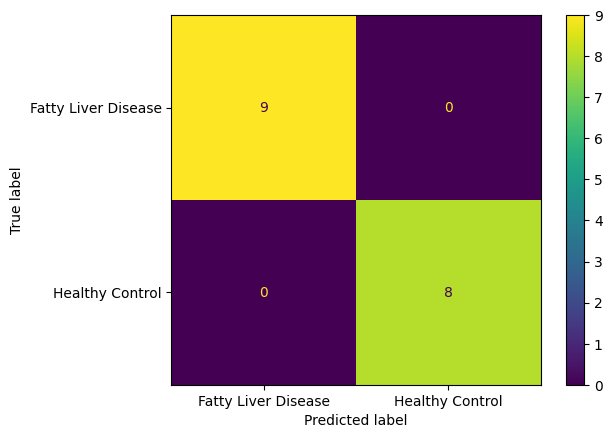

In [192]:
param_dist = [
    {
        'classifier__kernel': ['linear'],
        'classifier__C': np.logspace(-3, 3, 5),
    },
    
    # {
    #     'classifier__kernel': ['rbf'],
    #     'classifier__C': np.logspace(-3, 3, 5),
    #     'classifier__gamma': np.logspace(-3, 3, 5),
    # },
]

random_search_pipeline = RandomizedSearchCV(
    estimator=pipeline,                
    param_distributions=param_dist,  
    n_iter=200,                        
    cv=10,                            
    scoring='f1_weighted',             
    verbose=0,                   
    n_jobs=-1                          
)

print("\nStarting RandomizedSearchCV on Pipeline...")
random_search_pipeline.fit(X_train, y_train)
print("RandomizedSearchCV on Pipeline complete.")

print("\nBest hyperparameters found for the pipeline:")
print(random_search_pipeline.best_params_)

print("\nBest cross-validation score:")
print(random_search_pipeline.best_score_)

best_pipeline_model = random_search_pipeline.best_estimator_
print("\nBest Pipeline Model:")
print(best_pipeline_model)

y_pred_tuned = best_pipeline_model.predict(X_test)

print("\n--- Evaluation of Best Tuned Pipeline on Test Set ---")
svm_accuracy = accuracy_score(y_test, y_pred_tuned)
print(f"Accuracy: {svm_accuracy}")
print("\nClassification Report:")

svm_classfication_report = classification_report(y_test, y_pred_tuned, target_names=le.classes_, output_dict=True)
svm_classfication_report = pd.DataFrame(svm_classfication_report).transpose().drop('accuracy')
print(svm_classfication_report)

best_scaler = best_pipeline_model.named_steps['scaler']
best_classifier = best_pipeline_model.named_steps['classifier']

svm_conf_matrix = confusion_matrix(y_test, y_pred_tuned)
print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix=svm_conf_matrix,
                              display_labels=le.classes_)
disp.plot()
plt.show()

#### Feature Importance


--- Top 20 Most Relevant Features ---
               feature  importance
14527  ENSG00000182771    0.001341
7662   ENSG00000140391    0.001339
12193  ENSG00000170054    0.001271
1210   ENSG00000073734    0.001266
10865  ENSG00000164309    0.001265
12362  ENSG00000170881    0.001226
16515  ENSG00000198189    0.001199
2653   ENSG00000102962    0.001198
13566  ENSG00000177138    0.001183
6352   ENSG00000132475    0.001165
12727  ENSG00000172456    0.001147
15411  ENSG00000186910    0.001140
17495  ENSG00000202331    0.001133
4561   ENSG00000117507    0.001133
8679   ENSG00000147853    0.001130
4119   ENSG00000114248    0.001125
5129   ENSG00000122852    0.001120
12803  ENSG00000172828    0.001111
1751   ENSG00000088899    0.001107
5423   ENSG00000125144    0.001105


/Users/jaydn/Documents/GitHub/Human-Liver-RNA-Seq-Gene-Expression-Analysis/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jaydn/Documents/GitHub/Human-Liver-RNA-Seq-Gene-Expression-Analysis/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jaydn/Documents/GitHub/Human-Liver-RNA-Seq-Gene-Expression-Analysis/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


<Axes: xlabel='importance', ylabel='feature'>

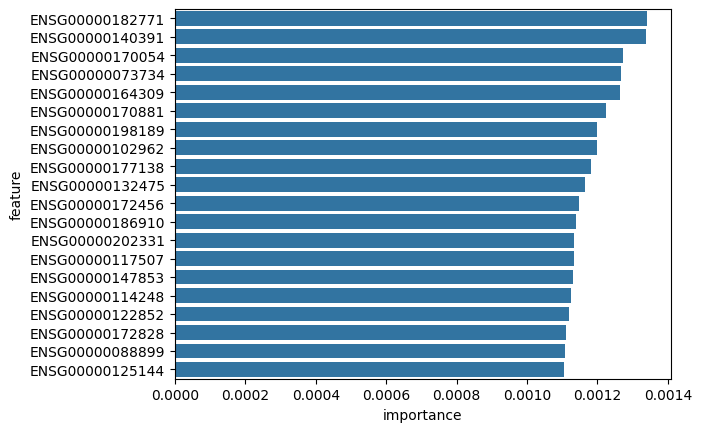

In [193]:
importances = np.abs(best_classifier.coef_[0])

feature_names = X_train.columns.tolist()

svm_feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

svm_feature_importance_df = svm_feature_importance_df.sort_values(by='importance', ascending=False)

print("\n--- Top 20 Most Relevant Features ---")
print(svm_feature_importance_df.head(20))

sns.barplot(x='importance', y='feature', data=svm_feature_importance_df.head(20))

## Gradient Boosted Decision Tree

#### Defining Pipline

In [194]:
pipeline_steps = [
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(
        device='cuda', 
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        scale_pos_weight=1.65))
]
pipeline = ImbPipeline(pipeline_steps)
print("\nDefined Pipeline:")
print(pipeline)


Defined Pipeline:
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device='cuda',
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=n

#### Training, Optimising and Results


Starting RandomizedSearchCV on Pipeline...


/Users/jaydn/Documents/GitHub/Human-Liver-RNA-Seq-Gene-Expression-Analysis/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:34:15] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:203: XGBoost is not compiled with CUDA support.
  bst.update(dtrain, iteration=i, fobj=obj)
/Users/jaydn/Documents/GitHub/Human-Liver-RNA-Seq-Gene-Expression-Analysis/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:34:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/jaydn/Documents/GitHub/Human-Liver-RNA-Seq-Gene-Expression-Analysis/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:34:15] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:203: XGBoost is not compiled with CUDA support.
  bst.update(dtrain, iteration=i, fobj=obj)
/Users/jaydn/Documents/GitHub/Human-Liver-RNA-Se

RandomizedSearchCV on Pipeline complete.

Best hyperparameters found for the pipeline:
{'classifier__class_weight': 'balanced', 'classifier__colsample_bytree': np.float64(0.5335895877254504), 'classifier__eval_metric': 'mlogloss', 'classifier__gamma': np.float64(0.0011535102960119968), 'classifier__learning_rate': np.float64(0.04863740813262379), 'classifier__max_depth': 2, 'classifier__min_child_weight': 3, 'classifier__n_estimators': 126, 'classifier__reg_alpha': np.float64(0.00015734901266523885), 'classifier__reg_lambda': np.float64(1.422426071438964e-08), 'classifier__subsample': np.float64(0.8976715028443074), 'classifier__use_label_encoder': False}

Best cross-validation score:
0.9103935280405867

Best Pipeline Model:
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               class_weight='balanced', colsample_bylevel=None,
                              

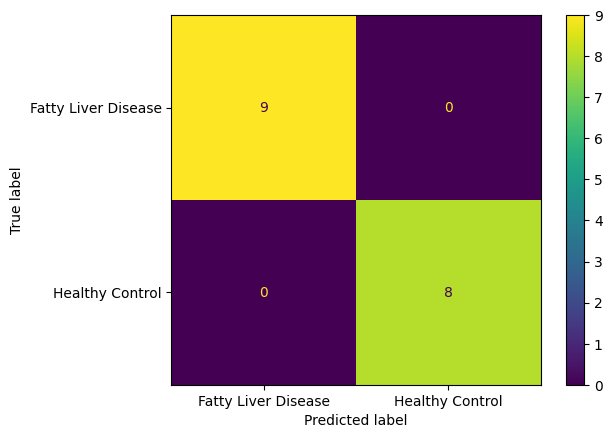

In [195]:
# good parameters
# {'classifier__class_weight': None, 'classifier__colsample_bytree': np.float64(0.8755909403702945), 'classifier__eval_metric': 'mlogloss', 'classifier__gamma': np.float64(0.00342149482772333), 'classifier__learning_rate': np.float64(0.009859525935595078), 'classifier__max_depth': 2, 'classifier__min_child_weight': 4, 'classifier__n_estimators': 392, 'classifier__reg_alpha': np.float64(1.4032073545864337e-05), 'classifier__reg_lambda': np.float64(0.0006988032796254695), 'classifier__subsample': np.float64(0.6430522399631521), 'classifier__use_label_encoder': False}


param_dist = {
    'classifier__n_estimators': randint(100, 500),
    'classifier__learning_rate': loguniform(0.001, 0.1),
    'classifier__max_depth': randint(1, 4),
    
    'classifier__colsample_bytree': uniform(0.5, 0.5), 
    
    'classifier__subsample': uniform(0.6, 0.4),
    'classifier__gamma': loguniform(1e-9, 1e-1),
    'classifier__min_child_weight': randint(1, 5),
    'classifier__reg_alpha': loguniform(1e-9, 1e-1),
    'classifier__reg_lambda': loguniform(1e-9, 1e-1),

    'classifier__eval_metric': ['mlogloss'],
    'classifier__use_label_encoder': [False],
    'classifier__class_weight': [None, 'balanced']
}

random_search_pipeline = RandomizedSearchCV(
    estimator=pipeline,                
    param_distributions=param_dist,  
    n_iter=20,                   
    cv=5,                         
    scoring='f1_weighted',         
    verbose=0,                   
    n_jobs=8                          
)

print("\nStarting RandomizedSearchCV on Pipeline...")
random_search_pipeline.fit(X_train, y_train)
print("RandomizedSearchCV on Pipeline complete.")

print("\nBest hyperparameters found for the pipeline:")
print(random_search_pipeline.best_params_)

print("\nBest cross-validation score:")
print(random_search_pipeline.best_score_)

best_pipeline_model = random_search_pipeline.best_estimator_
print("\nBest Pipeline Model:")
print(best_pipeline_model)

y_pred_tuned = best_pipeline_model.predict(X_test)

print("\n--- Evaluation of Best Tuned Pipeline on Test Set ---")
xgb_accuracy = accuracy_score(y_test, y_pred_tuned)
print(f"Accuracy: {xgb_accuracy}")

# print("\nClassification Report:")
xgb_classification_report = classification_report(y_test, y_pred_tuned, target_names=le.classes_, output_dict=True)
xgb_classification_report = pd.DataFrame(xgb_classification_report).transpose().drop('accuracy')
print(xgb_classification_report)

best_scaler = best_pipeline_model.named_steps['scaler']
best_classifier = best_pipeline_model.named_steps['classifier']

xgb_conf_matrix = confusion_matrix(y_test, y_pred_tuned)
print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix=xgb_conf_matrix,
                              display_labels=le.classes_)
disp.plot()
plt.show()

#### Feature Importance


--- Top 20 Most Relevant Features ---
               feature  importance
15953  ENSG00000196187    0.091478
12496  ENSG00000171453    0.055324
14589  ENSG00000183049    0.050219
6322   ENSG00000132329    0.046792
14527  ENSG00000182771    0.044932
6926   ENSG00000136011    0.044732
647    ENSG00000049323    0.041988
1276   ENSG00000075391    0.041518
3264   ENSG00000106991    0.034726
6783   ENSG00000135318    0.026293
2372   ENSG00000101138    0.026173
11953  ENSG00000168913    0.024176
1224   ENSG00000074181    0.021220
13262  ENSG00000175445    0.020906
9415   ENSG00000154654    0.018619
11928  ENSG00000168806    0.018555
8751   ENSG00000148468    0.017565
2999   ENSG00000105392    0.017140
8084   ENSG00000143436    0.014726
12926  ENSG00000173482    0.014530


<Axes: xlabel='importance', ylabel='feature'>

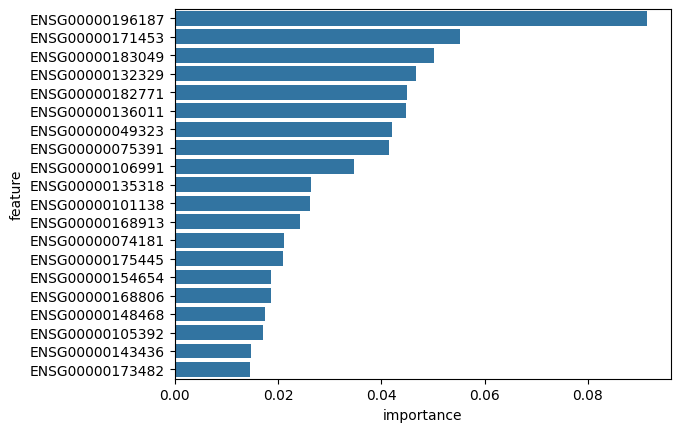

In [196]:
best_classifier = best_pipeline_model.named_steps['classifier']
importances = best_classifier.feature_importances_

feature_names = X_train.columns.tolist()

xgb_feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

xgb_feature_importance_df = xgb_feature_importance_df.sort_values(by='importance', ascending=False)

print("\n--- Top 20 Most Relevant Features ---")
print(xgb_feature_importance_df.head(20))

sns.barplot(x='importance', y='feature', data=xgb_feature_importance_df.head(20))

## Random Forest

#### Defining Pipline

In [197]:
pipeline_steps = [
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier())
]
pipeline = ImbPipeline(pipeline_steps)
print("\nDefined Pipeline:")
print(pipeline)


Defined Pipeline:
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', RandomForestClassifier())])


#### Training, Optimising and Results


Starting RandomizedSearchCV on Pipeline...
RandomizedSearchCV on Pipeline complete.

Best hyperparameters found for the pipeline:
{'classifier__n_estimators': 250, 'classifier__min_samples_split': 20, 'classifier__min_samples_leaf': 5, 'classifier__max_features': 0.1, 'classifier__max_depth': 5, 'classifier__bootstrap': True}

Best cross-validation score:
0.910818070818071

Best Pipeline Model:
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 RandomForestClassifier(max_depth=5, max_features=0.1,
                                        min_samples_leaf=5,
                                        min_samples_split=20,
                                        n_estimators=250))])

--- Evaluation of Best Tuned Pipeline on Test Set ---
Accuracy: 1.0
                     precision  recall  f1-score  support
Fatty Liver Disease        1.0     1.0       1.0      9.0
Healthy Control            1.0     1.0       1.0      8.0
macro avg                  

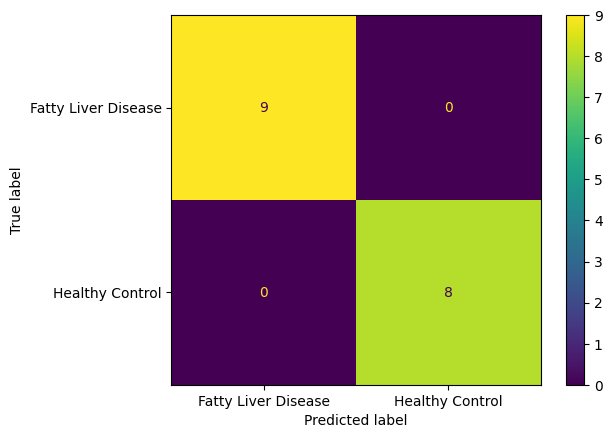

In [198]:
# good parameters:
# {'classifier__n_estimators': 250, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 5, 'classifier__max_features': 0.1, 'classifier__max_depth': None, 'classifier__bootstrap': True}

param_dist = {

    'classifier__n_estimators': [100, 250, 500, 1000],

    'classifier__max_features': ['sqrt', 'log2', 0.05, 0.1], 
    
    'classifier__max_depth': [3, 5, 10, 15, 20, None],

    'classifier__min_samples_split': [2, 5, 10, 20],

    'classifier__min_samples_leaf': [1, 2, 5, 10],

    'classifier__bootstrap': [True] 
}
  
random_search_pipeline = RandomizedSearchCV(
    estimator=pipeline, 
    param_distributions=param_dist,
    scoring='f1_weighted',  
    n_iter=100, 
    cv=5, 
    verbose=0, 
    random_state=42, 
    n_jobs=-1)

print("\nStarting RandomizedSearchCV on Pipeline...")
random_search_pipeline.fit(X_train, y_train)
print("RandomizedSearchCV on Pipeline complete.")

print("\nBest hyperparameters found for the pipeline:")
print(random_search_pipeline.best_params_)

print("\nBest cross-validation score:")
print(random_search_pipeline.best_score_)

best_pipeline_model = random_search_pipeline.best_estimator_
print("\nBest Pipeline Model:")
print(best_pipeline_model)

y_pred_tuned = best_pipeline_model.predict(X_test)

print("\n--- Evaluation of Best Tuned Pipeline on Test Set ---")
random_forest_accuracy = accuracy_score(y_test, y_pred_tuned)
print(f"Accuracy: {random_forest_accuracy}")
# print("\nClassification Report:")
random_forest_classification_report = classification_report(y_test, y_pred_tuned, target_names=le.classes_, output_dict=True)
random_forest_classification_report = pd.DataFrame(random_forest_classification_report).transpose().drop('accuracy')
print(random_forest_classification_report)

best_scaler = best_pipeline_model.named_steps['scaler']
best_classifier = best_pipeline_model.named_steps['classifier']

random_forest_conf_matrix = confusion_matrix(y_test, y_pred_tuned)
print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix=random_forest_conf_matrix,
                              display_labels=le.classes_)
disp.plot()
plt.show()

#### Feature Importance


--- Top 20 Most Relevant Features ---
               feature  importance
12496  ENSG00000171453    0.049994
14589  ENSG00000183049    0.032191
6322   ENSG00000132329    0.031661
15953  ENSG00000196187    0.028729
14527  ENSG00000182771    0.027483
12926  ENSG00000173482    0.026675
1920   ENSG00000092421    0.023561
4782   ENSG00000119711    0.018841
12426  ENSG00000171132    0.016927
3264   ENSG00000106991    0.016901
2032   ENSG00000099284    0.015922
8084   ENSG00000143436    0.012262
2591   ENSG00000102390    0.011318
11928  ENSG00000168806    0.011071
3098   ENSG00000105849    0.010092
19569  ENSG00000231925    0.009757
9415   ENSG00000154654    0.009300
19883  ENSG00000237991    0.008596
12537  ENSG00000171606    0.008202
2125   ENSG00000100097    0.008176


<Axes: xlabel='importance', ylabel='feature'>

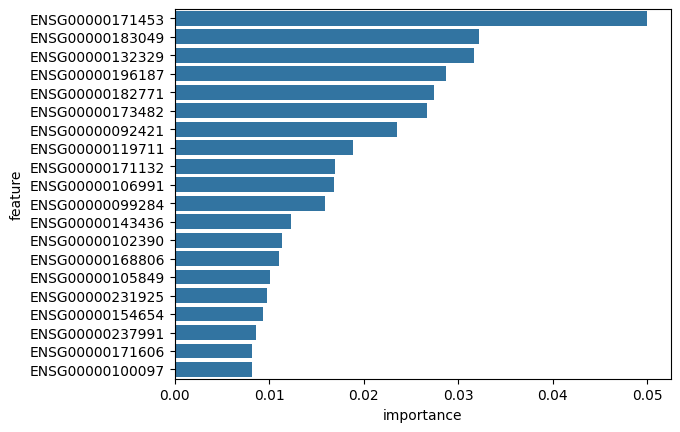

In [199]:
best_classifier = best_pipeline_model.named_steps['classifier']
importances = best_classifier.feature_importances_

feature_names = X_train.columns.tolist()

random_forest_feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

random_forest_feature_importance_df = random_forest_feature_importance_df.sort_values(by='importance', ascending=False)

print("\n--- Top 20 Most Relevant Features ---")
print(random_forest_feature_importance_df.head(20))

sns.barplot(x='importance', y='feature', data=random_forest_feature_importance_df.head(20))

## Evaluation

#### Comparison of Accuracy

<BarContainer object of 3 artists>

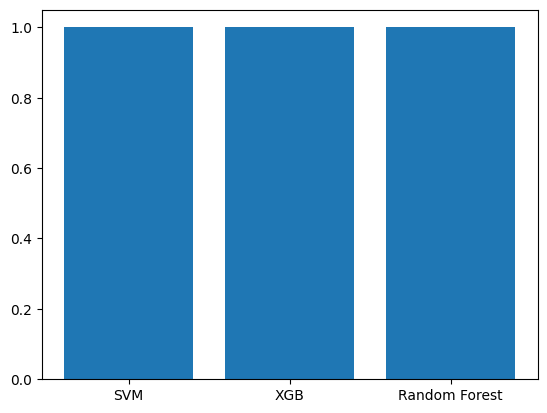

In [200]:
x = ["SVM", "XGB", "Random Forest"]
y = [svm_accuracy, xgb_accuracy, random_forest_accuracy]

plt.bar(x,y)


#### Comparison of Confusion Matrices

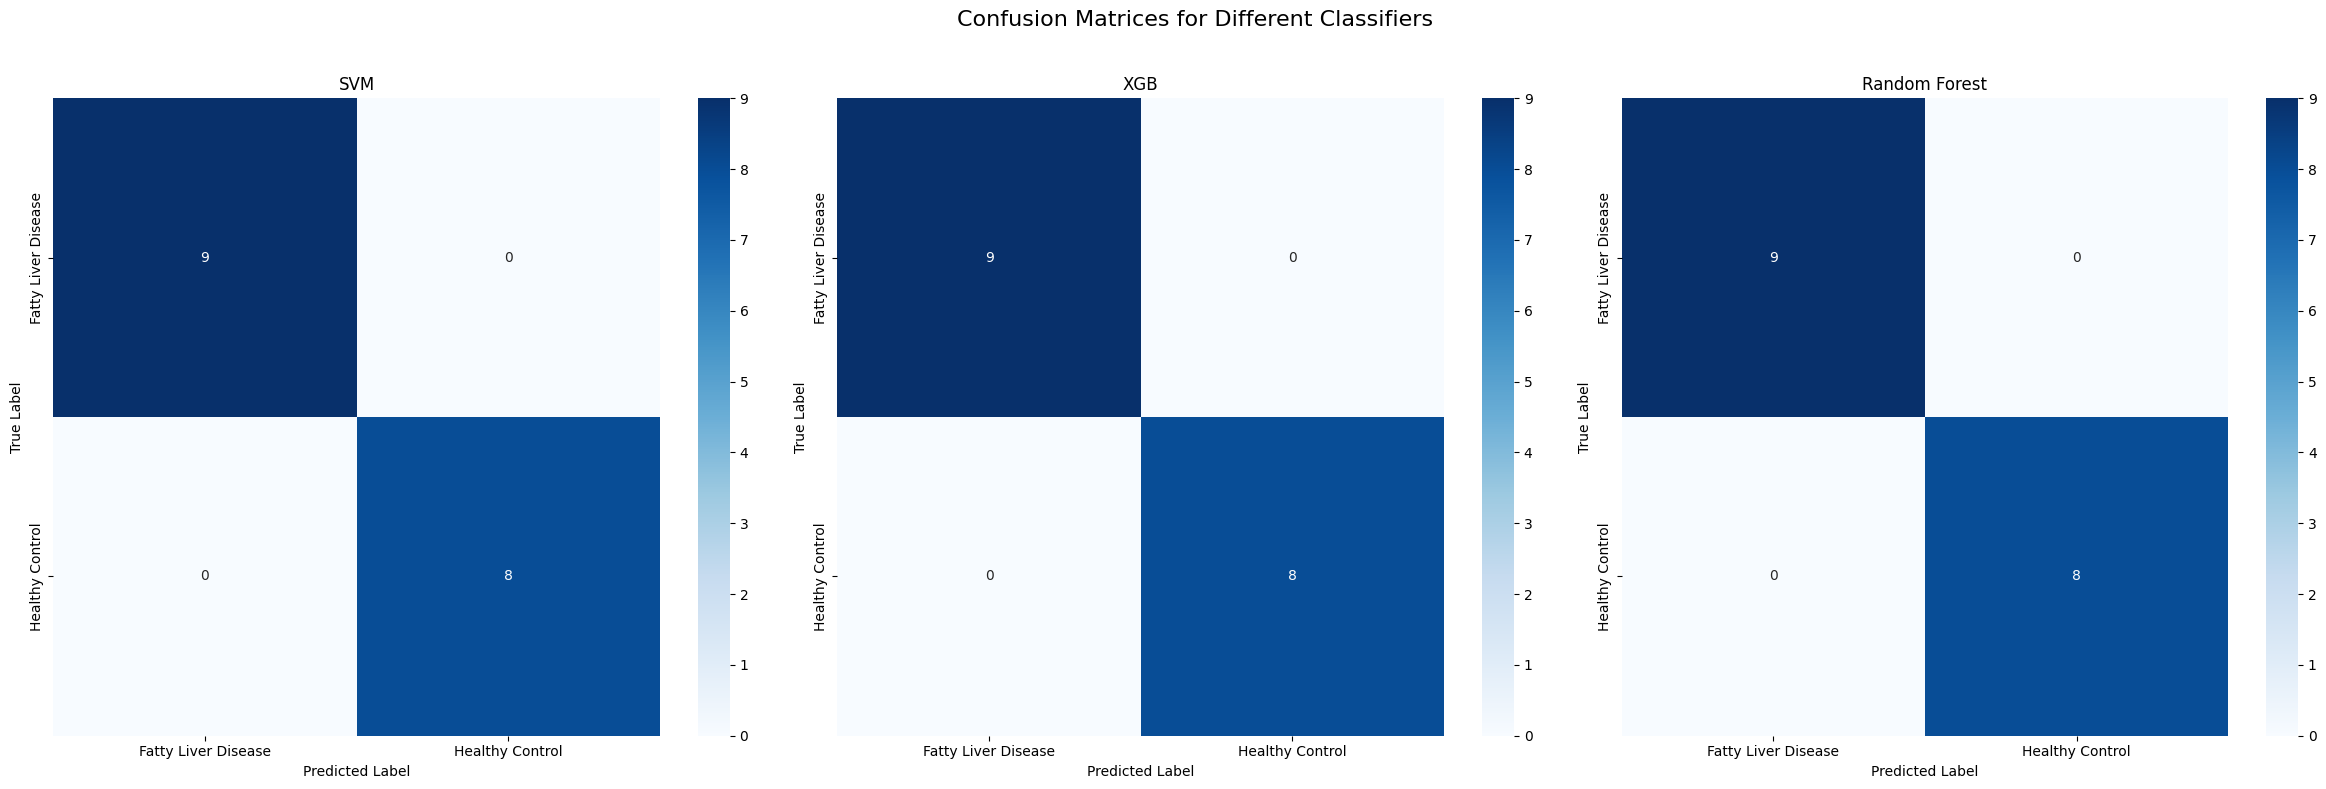

In [201]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

matrices = [svm_conf_matrix, xgb_conf_matrix, random_forest_conf_matrix]
titles = ['SVM', 'XGB', 'Random Forest']

for i, (matrix, title) in enumerate(zip(matrices, titles)):
    sns.heatmap(matrix, 
                ax=axes[i], 
                annot=True, 
                fmt="d", 
                cmap="Blues", 
                xticklabels=le.classes_, 
                yticklabels=le.classes_)
    axes[i].set_title(title)
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

fig.suptitle('Confusion Matrices for Different Classifiers', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.show()

#### Comparision of Important Features

In [202]:
frames = [svm_feature_importance_df.head(20), xgb_feature_importance_df.head(20), random_forest_feature_importance_df.head(20)]

combined_frames = pd.concat(frames)

combined_frames = combined_frames.drop(columns='importance')

values_counts = combined_frames.value_counts()

feature_counts_df = values_counts.reset_index()
feature_counts_df.columns = ['feature', 'model_count']

print("--- Features by Consensus Importance ---")
print("---------------------------------------")
print("Feature        | Appears in (Models) |")
print("---------------------------------------")
for _, row in feature_counts_df.head(20).iterrows():
    print(f"{row['feature']:<14} | {row['model_count']:<19} |")
print("---------------------------------------")

--- Features by Consensus Importance ---
---------------------------------------
Feature        | Appears in (Models) |
---------------------------------------
ENSG00000182771 | 3                   |
ENSG00000143436 | 2                   |
ENSG00000168806 | 2                   |
ENSG00000132329 | 2                   |
ENSG00000171453 | 2                   |
ENSG00000106991 | 2                   |
ENSG00000173482 | 2                   |
ENSG00000154654 | 2                   |
ENSG00000183049 | 2                   |
ENSG00000196187 | 2                   |
ENSG00000171132 | 1                   |
ENSG00000164309 | 1                   |
ENSG00000231925 | 1                   |
ENSG00000168913 | 1                   |
ENSG00000170054 | 1                   |
ENSG00000202331 | 1                   |
ENSG00000170881 | 1                   |
ENSG00000198189 | 1                   |
ENSG00000177138 | 1                   |
ENSG00000171606 | 1                   |
---------------------------------------


### Common Sets of Importance Features

- ENSG00000182771
- ENSG00000164309
- ENSG00000075391
- ENSG00000132329
- ENSG00000170006
- ENSG00000171132
- ENSG00000135318
- ENSG00000175336
- ENSG00000183049
- ENSG00000198189

- ENSG00000182771
- ENSG00000143436
- ENSG00000168806
- ENSG00000132329
- ENSG00000171453
- ENSG00000106991
- ENSG00000173482
- ENSG00000154654
- ENSG00000183049
- ENSG00000196187

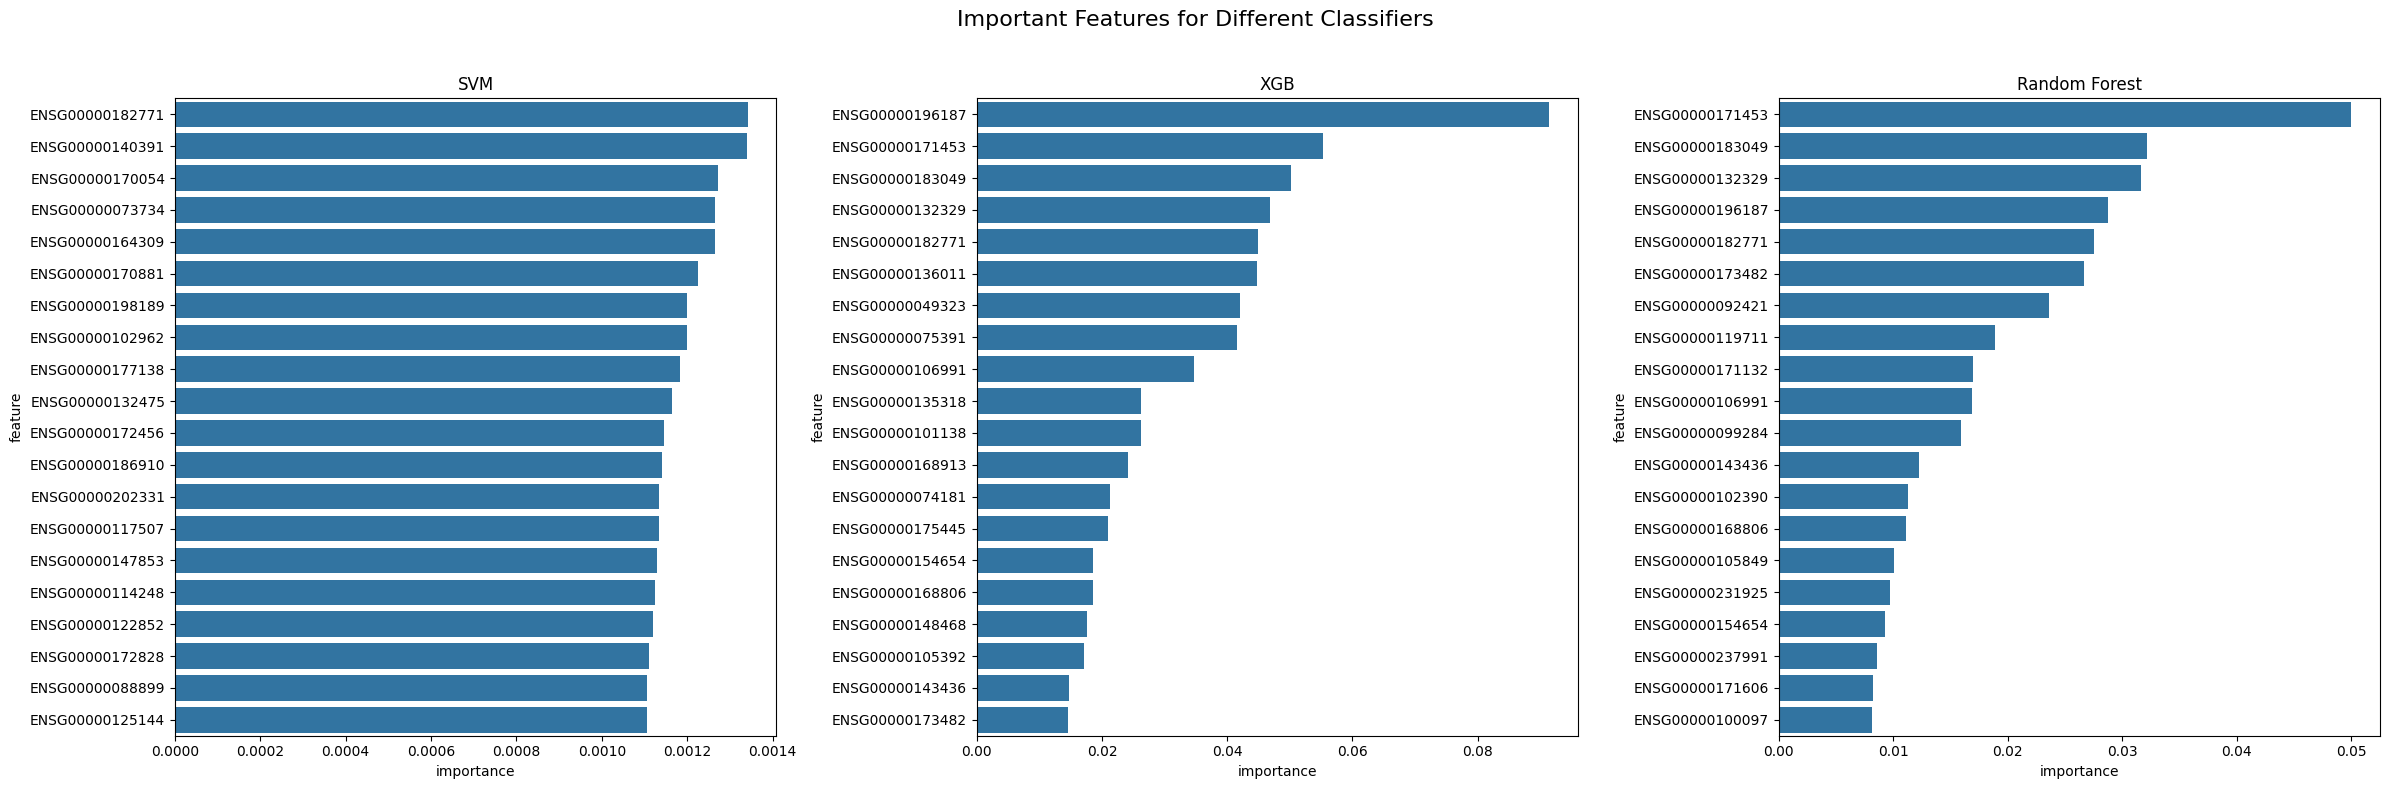

In [203]:

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

matrices = [svm_feature_importance_df, xgb_feature_importance_df, random_forest_feature_importance_df]
titles = ['SVM', 'XGB', 'Random Forest']

for i, (matrix, title) in enumerate(zip(matrices, titles)):
    sns.barplot(x='importance', y='feature', data=matrix.head(20), ax=axes[i],)
    axes[i].set_title(title)

fig.suptitle('Important Features for Different Classifiers', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.show()

#### Comparision of Classification Reports

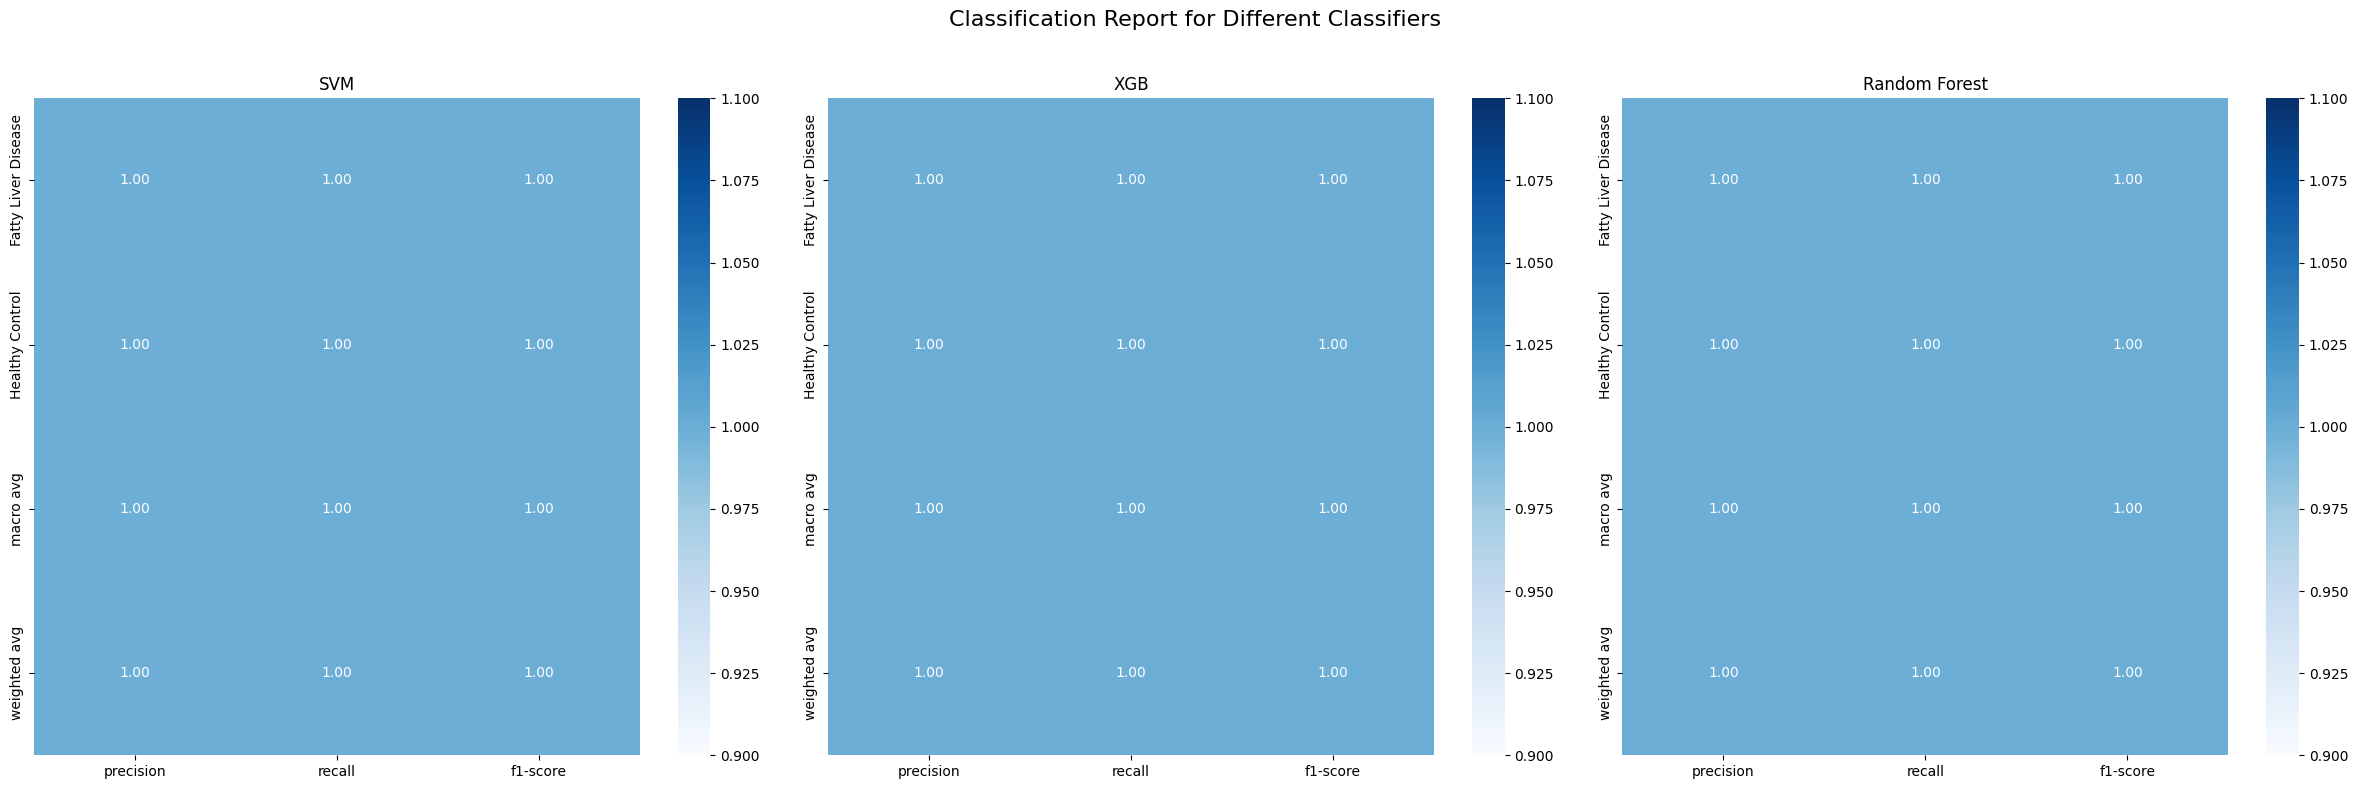

In [204]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
svm_classfication_report = svm_classfication_report.drop(columns="support", errors="ignore")
xgb_classification_report = xgb_classification_report.drop(columns="support", errors="ignore")
random_forest_classification_report = random_forest_classification_report.drop(columns="support", errors="ignore")

matrices = [svm_classfication_report, xgb_classification_report, random_forest_classification_report]
titles = ['SVM', 'XGB', 'Random Forest']

for i, (matrix, title) in enumerate(zip(matrices, titles)):
    sns.heatmap(matrix, annot=True, fmt=".2f", ax=axes[i], cmap="Blues")
    axes[i].set_title(title)

fig.suptitle('Classification Report for Different Classifiers', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.show()